# LangGraph

* State 정의 -> Node 함수 -> add_node -> add_edge / 조건부 Edge -> compile -> invoke · stream

## 0. 전체 흐름

### 0.1 계단지도
[뼈대]   
1. concept - State·Node·Edge 세 부품, compile·invoke·stream
2. state - State 합치는 규칙: 덮어쓰기 / 누적 / 메세지
3. node_edge - Edge 모양: 순차, 갈라지기, 모이기
4. conditional - 조건부 Edge, 루프, 반복 횟수 제한

[모델 넣기]   
5. llm_chatbot - 노드 안에서 LLM 호출, MessageState 챗봇   
6. tool_agent - ToolNode + tools_condition = ReAct 루프   

[실전 파이프라인]   
7-1. search - 외부 검색 API(Tavily)를 노드 하나로   
7-2. report - 검색 뒤에 LLM 리포트 노드   
7-3. loop - 검증 노드 + 검색어 재작성 루프   
7-4. summary - 기사별 요약 노드, 요약 품질로 검증

### 0.2 기본코드

In [ ]:
# 1. State: 그래프가 들고 다닐 칸을 정한다
class MyState(TypeDict):
    question: str
    answer: str

# 2. Node: State를 받아서, 바꾼 칸만 dict로 돌려주는 함수
def answer_node(state: MyState) -> dict:
    return {"answer": '...'}

# 3. 빌더를 만들고 노드를 등록한다
builder = StateGraph(MyState)
builder.add_node("답변", answer_node)

# 4. Edge로 순서를 정한다 (조건이 있으면 add_conditinal_edges)
builder.add_edge(START, "답변")
builder.add_edge("답변", END)

# 5. 실행 가능한 물건으로 굳힌다
app = builder.compile()

# 6. 실행한다: 끝까지 한 번에(invoke) 또는 한 단계씩(stream)
result = app.invoke({"question": "...", "answer": ""})

## 1. LangGraph?
* State - 그래프 전체가 공유하는 데이터 저장소
* Node - State를 받아 처리하고 바꾼 부분을 돌려주는 함수
* Edge - 노드 간 실행 순서

In [20]:
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

load_dotenv()

True

In [19]:
# State정의: 그래프 전체에서 공유되는 데이터 구조
class CalcState(TypedDict):
    num1: int
    num2: int
    result: int

# State는 단순히 TypeDict 클래스임
print("State 정의 완료", CalcState.__annotations__)

# Node 정의: State를 입력으로 받아 처리 후 업데이트된 딕셔너리 반환
def add_node(state: CalcState) -> dict:
    """두 숫자를 더하는 노드"""
    result = state["num1"] + state["num2"]
    return {"result": result}

def multiply_node(state: CalcState) -> dict:
    """두 숫자를 곱하는 노드"""
    result = state["num1"] * state["num2"]
    return {"result": result}

def print_result(state: CalcState) -> dict[str, int]:
    """Node 3: 결과를 저장한다"""
    print(f"[결과 노드] 최종 결과 = {state['result']}")
    return {"result": state["result"]}

# 그래프 빌더 생성 (State 타입을 지정)
builder = StateGraph(CalcState)

# Node 등록(이름, 함수)
builder.add_node("add", add_node)
builder.add_node("multiply", multiply_node)
builder.add_node("print_result", print_result)

# Edge 연결 (실행 순서 정의)
builder.add_edge(START, "add")
builder.add_edge("add", "multiply")
builder.add_edge("multiply", "print_result")
builder.add_edge("print_result", END)

# 그래프 컴파일 (실행 가능한 상태로 변환)
graph = builder.compile()

def show_graph(app, title: str = "") -> None:
    if title:
        print(f"\n[{title}]")
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())

# [실행]
# invoke(): 초기 State를 입력해서 실행
initial_state = {"num1": 5, "num2": 10, "result": 0}
final_state = graph.invoke(initial_state)
print(f"\n최종 State: {final_state}")
print(f"계산 결과: ({initial_state['num1']} + {initial_state['num2']}) * 2 = {final_state['result']}")
print("-" * 50)

# stream(): 각 노드의 실행 결과를 실시간으로 확인
for step in graph.stream({"num1": 3, "num2": 4, "result": 0}):
    node_name = list(step.keys())[0]
    node_output = step[node_name]
    print(f"[{node_name}] 출력: {node_output}")

State 정의 완료 {'num1': <class 'int'>, 'num2': <class 'int'>, 'result': <class 'int'>}
[결과 노드] 최종 결과 = 50

최종 State: {'num1': 5, 'num2': 10, 'result': 50}
계산 결과: (5 + 10) * 2 = 50
--------------------------------------------------
[add] 출력: {'result': 7}
[multiply] 출력: {'result': 12}
[결과 노드] 최종 결과 = 12
[print_result] 출력: {'result': 12}


## 2. State - 덮어쓰기, 누적, 메세지

### 2.1 기본 규칙 - 병합

In [23]:
class BasicState(TypedDict):
    name: str
    count: int
    message: str

def node_a(state: BasicState) -> dict:
    print(f"[NodeA] 입력: count = {state['count']}")
    return {"count": state['count'] + 1, "message": "A 실행 완료"}

def node_b(state: BasicState) -> dict:
    print(f"[NodeB] 입력: count = {state['count']}")
    return {"count": state['count'] + 10, "message": "B 실행 완료"}

# START -> A -> B -> END 연결
builder = StateGraph(BasicState)

builder.add_node("A", node_a)
builder.add_node("B", node_b)

builder.add_edge(START, "A")
builder.add_edge("A", "B")
builder.add_edge("B", END)
app = builder.compile()

result = app.invoke({"name": "홍길동", "count": 0, "message": ""})

[NodeA] 입력: count = 0
[NodeB] 입력: count = 1


### 2.2 누적 - Annotated[..., operator.add]

In [29]:
import operator
from typing import Annotated

class AccumulateState(TypedDict):
    # Annotated[타입, reducer함수] -> 반환값을 기존 값에 더함
    history: Annotated[list[str], operator.add]
    total: int

def step1(state): return {"history": ["step1 실행"], "total": 1}
def step2(state): return {"history": ["step2 실행"], "total": 2}
def step3(state): return {"history": ["step3 실행"], "total": 3}

builder = StateGraph(AccumulateState)

builder.add_node("step1", step1)
builder.add_node("step2", step2)
builder.add_node("step3", step3)

builder.add_edge(START, "step1")
builder.add_edge("step1", "step2")
builder.add_edge("step2", "step3")
builder.add_edge("step3", END)

graph = builder.compile()

result = graph.invoke({"history": [], "total": 0})
print(result)

{'history': ['step1 실행', 'step2 실행', 'step3 실행'], 'total': 3}


### 2.3 메시지 전용 - MessageState

In [52]:
from langchain_core.messages import BaseMessage

class MessagesState(TypedDict):
    messages = Annotated[list(BaseMessage), add_messages]

def n1(state): return {"messages": [AIMessage(content="초안", id="m1")]}
def n2(state): return {"messages": [AIMessage(content="수정본", id="m1")]}

builder = StateGraph(MessagesState)

builder.add_node("n1", n1)
builder.add_node("n2", n2)

builder.add_edge(START, "n1")
builder.add_edge("n1", "n2")
builder.add_edge("n2", END)

graph = builder.compile()

res = graph.invoke({"messages": [HumanMessage(content="안녕")]})
print([(type(m).__name__, m.content) for m in res["messages"]])

TypeError: 'ModelMetaclass' object is not iterable

### 2.4 NotRequired

In [ ]:
from typing import TypedDict

class NoticeState(TypedDict):
    draft: str
    retry_count: int
    next_step: NotRequired[str]
    final_text: NotRequired[str]

In [32]:
# State를 pydantic으로 쓰기
from pydantic import BaseModel, Field

class NoticeState(BaseModel):
    draft: str = Field(description="현재 공지 초안 문장")
    retry_count: int = Field(default=0, description="초안을 다시 보완한 횟수")
    next_step: str | None = Field(default=None, description="실행 중에 정해지는 다음 노드 이름")
    final_text: str | None = Field(default=None, description="최종 단계에서 채워지는 공지 문장")

## 3. Node와 Edge - 순차, 갈라지기, 모이기

### 3.1 순차 실행과 "실행기록"칸

In [36]:
class PipelineState(TypedDict):
    text: str                               # 현재 처리 중인 텍스트 (덮어쓰기)
    steps: Annotated[list, operator.add]    # 지금까지 실행된 단계 (누적)

def clean(state: PipelineState) -> dict:
    cleaned = state["text"].strip().lower()
    return {"text": cleaned, "steps": ["전처리"]}

def translate(state: PipelineState) -> dict:
    translated = state["text"].replace("hello", "안녕")
    return {"text": translated, "steps": ["번역"]}

def format_text(state: PipelineState) -> dict:
    formatted = f"[결과] {state['text'].upper()}"
    return {"text": formatted, "steps": ["포맷"]}

b = StateGraph(PipelineState)

b.add_node("전처리", clean)
b.add_node("번역", translate)
b.add_node("포맷", format_text)

b.add_edge(START, "전처리")
b.add_edge("전처리", "번역")
b.add_edge("번역", "포맷")
b.add_edge("포맷", END)

app = b.compile()

result = app.invoke({"text": "Hello world", "steps": []})
print(result)


{'text': '[결과] 안녕 WORLD', 'steps': ['전처리', '번역', '포맷']}


### 3.2 Fan-out / Fan-in

In [38]:
class FanState(TypedDict):
    value: int
    # 병렬 노드들이 같은 ket를 동시에 업데이트 할 수 있으므로 reducer가 필요
    results: Annotated[list[str], operator.add]

def start_node(state: FanState) -> dict:
    print(f"[시작] value={state['value']}")
    return {}   # 변경할 State가 없으면 빈 dict

def path_a(state: FanState) -> dict:
    r = state["value"] * 2
    print(f"[경로 A] {state['value']} x 2 = {r}")
    return {"results": [f"A결과 = {r}"]}

def path_b(state: FanState) -> dict:
    r = state["value"] + 100
    print(f"[경로 B] {state['value']} + 100 = {r}")
    return {"result": [f"B결과 = {r}"]}

def merge_node(state: FanState) -> dict:
    print(f"[합산] 수집된 결과: {state['results']}")
    return {}

b = StateGraph(FanState)

b.add_node("시작", start_node); 
b.add_node("경로A", path_a)
b.add_node("경로B", path_b);    
b.add_node("합산", merge_node)

b.add_edge(START, "시작")
b.add_edge("시작", "경로A")      # Fan-out: 한 노드에서 Edge 두 개
b.add_edge("시작", "경로B")
b.add_edge(["경로A", "경로B"], "합산")   # Fan-in: 둘 다 끝나면 합산
b.add_edge("합산", END)

graph = b.compile()

result = graph.invoke({"value": 5, "results": []})

[시작] value=5
[경로 A] 5 x 2 = 10
[경로 B] 5 + 100 = 105
[합산] 수집된 결과: ['A결과 = 10']


## 4. 조건부 Edge와 루프
* 작업 -> 판정 -> (통과 | 다시)

In [ ]:
# 핵심 메서드
builder.add_conditional_edges(
    "노드이름",         # 이 노드가 끝나면 라우팅 함수가 실행됨
    routing_function, # State를 받아 "다음 경로 이름"(문자열)을 반환하는 함수
    path_map          # 선택: {반환값: 실제 노드 이름} 딕셔너리
)

#### Node vs Router
* Node: 일을 하고 State를 바꿈(딕셔너리 반환)
* Router: State를 보고 길만 고름(문자열 반환)   
-> 판단은 라우터에게 맡기고, 채점 노드는 그냥 "여기가 갈림길"이라는 자리만 잡아둔 것   
-> 판단 결과를 State에 남겨야 하나?   
    : 남겨야 하면(나중에 리포트에 적을 이유, 로그 등) 판정 노드가 State에 쓰고 라우터는 그걸 읽기만 하게 만듦   
    : 검증노드와 route_after_validation   

### 4.1 add_conditional_edges(노드, 라우터, path_map)

In [41]:
class GradeState(TypedDict):
    score: int
    grade: str
    message: str

def score_node(state: GradeState) -> dict:
    print(f"[채점] 점수: {state['score']}점")
    return {}

def grade_a(state: GradeState) -> dict:
    print("[우수반] A등급 배정")
    return {"grade": "A", "message": "축하합니다 ! 우수반에 배정되었습니다."}

def grade_b(state: GradeState) -> dict:
    print("[보통반] B등급 배정")
    return {"grade": "B", "message": "보통반에 배정되었습니다."}

def grade_c(state: GradeState) -> dict:
    print("[기초반] C등급 배정")
    return {"grade": "C", "message": "기초반에 배정되었습니다. 화이팅 !"}

def route_by_score(state: GradeState) -> str:
    score = state["score"]
    if score >= 90:
        return "우수반"
    elif score >= 70:
        return "보통반"
    else:
        return "기초반"

b = StateGraph(GradeState)

b.add_node("채점", score_node)
b.add_node("우수반", grade_a)
b.add_node("보통반", grade_b)
b.add_node("기초반", grade_c)

b.add_edge(START, "채점")
b.add_conditional_edges(
    "채점",
    route_by_score,
    {
        "우수반": "우수반",
        "보통반": "보통반",
        "기초반": "기초반"
    }
)
b.add_edge("우수반", END)
b.add_edge("보통반", END)
b.add_edge("기초반", END)

app = b.compile()

for score in [95, 75, 55]:
    print(f"\n=== 점수: {score} ===")
    result = app.invoke({"score": score, "grade": "", "message": ""})
    print(f"  결과: {result['grade']}등급 → {result['message']}")


=== 점수: 95 ===
[채점] 점수: 95점
[우수반] A등급 배정
  결과: A등급 → 축하합니다 ! 우수반에 배정되었습니다.

=== 점수: 75 ===
[채점] 점수: 75점
[보통반] B등급 배정
  결과: B등급 → 보통반에 배정되었습니다.

=== 점수: 55 ===
[채점] 점수: 55점
[기초반] C등급 배정
  결과: C등급 → 기초반에 배정되었습니다. 화이팅 !


### 4.2 루프: 라우터가 "앞의 노드 이름"을 돌려주면

In [42]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class CountState(TypedDict):
    count: int
    target: int

def increment_node(state):
    return {"count": state["count"] + 1}

def check_done(state) -> str:
    if state["count"] >= state["target"]:
        return "done"
    return "continue"


builder = StateGraph(CountState)

builder.add_node("increment", increment_node)

builder.add_edge(START, "increment")
builder.add_conditional_edges(
    "increment",
    check_done,
    {
        "done": END,
        "continue": "increment"
    }
)
graph = builder.compile()

for step in graph.stream({"count": 0, "target": 5}):
    print(step)


{'increment': {'count': 1}}
{'increment': {'count': 2}}
{'increment': {'count': 3}}
{'increment': {'count': 4}}
{'increment': {'count': 5}}


### 4.3 탈출조건: 목표달성, 횟수초과(MAX_ITER)

In [43]:
MAX_ITER = 5

def refine(state):
    next_attempt = state["attempts"] + 1
    new_quality = min(state["quality"] + 30, 100)
    new_text = state["text"] + f"[개선]{state['attempts']+1}차"
    return {"text": new_text, "quality": new_quality, "attempts": next_attempt}

def quality_gate(state) -> str:
    if state["quality"] >= 80:
        return "완료"

    if state["attempts"] >= MAX_ITER:
        return "완료"

    return "정제"

## 5. LLM 챗봇 그래프

In [46]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

def chatbot_node(state: MessagesState) -> dict:
    """사용자 메세지를 LLM에 전달하고 AI 응답을 State에 추가한다."""
    response = llm.invoke(state["messages"]) # 대화 전체를 그대로 모델에
    return {"messages": [response]}          # add_messages가 뒤에 붙여 줌

builder = StateGraph(MessagesState)

builder.add_node("챗봇", chatbot_node)

builder.add_edge(START, "챗봇")
builder.add_edge("챗봇", END)

app = builder.compile()

result = app.invoke({"messages": [HumanMessage(content="파이썬이 뭔가요? 한 문장으로 설명해줘")]})
print(result["messages"][-1].content)

파이썬은 간결하고 읽기 쉬운 문법을 가진 고급 프로그래밍 언어로, 다양한 분야에서 사용됩니다.


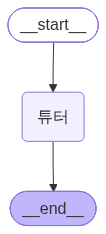

In [55]:
SYSTEM_PROMPT = """당신은 친절한 파이썬 튜터입니다.
- 초보자도 이해할 수 있게 쉽게 설명하세요
- 핵심만 간결하게 답변하세요
- 예시 코드는 짧게 보여주세요"""

def tutor_node(state: MessagesState) -> dict:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]

    response = llm.invoke(messages)
    return {"messages": [response]}

builder = StateGraph(MessagesState)

builder.add_node("튜터", tutor_node)

builder.add_edge(START, "튜터")
builder.add_edge("튜터", END)

app2 = builder.compile()

try:
    show_graph(app2)
except:
    print(app2.get_graph().draw_ascii())

In [56]:

# 멀티턴 - checkpointer없이 손으로

from langchain_core.messages import BaseMessage

def chat_session(app, questions: list[str], system: str = "") -> list[BaseMessage]:
    """여러 질문을 순서대로 실행하면서 messages를 직접 누적한다."""
    messages: list[BaseMessage] = []

    for i, question in enumerate(questions, 1):
        messages.append(HumanMessage(content=question)) # 1) 새 질문 추가
        result = app.invoke({"messages": messages})     # 2) 지금까지 전체를 넣어 실행
        messages = result["messages"]                   # 3) AI 답까지 포함한 전체로 교체
        ai_response = result["messages"][-1]
        print(f"[{i}] 사용자: {question}")
        print(f"AI: {ai_response.content}")
    return messages


conversation = chat_session(app2, questions=[
    "내 이름은 민준이에요.",
    "파이썬 딕셔너리가 뭔가요?",
    "제 이름이 뭐라고 했죠?",   # 문맥 기억 테스트
])


[1] 사용자: 내 이름은 민준이에요.
AI: 안녕하세요, 민준님! 반갑습니다. 파이썬에 대해 궁금한 점이 있으면 언제든지 물어보세요!
[2] 사용자: 파이썬 딕셔너리가 뭔가요?
AI: 파이썬 딕셔너리(Dictionary)는 키(key)와 값(value) 쌍으로 데이터를 저장하는 자료형입니다. 키를 사용해 값을 빠르게 찾을 수 있습니다.

예시:
```python
# 딕셔너리 생성
person = {
    "name": "민준",
    "age": 25,
    "city": "서울"
}

# 값 접근
print(person["name"])  # 민준
```

여기서 `"name"`, `"age"`, `"city"`가 키이고, 각각의 값은 `"민준"`, `25`, `"서울"`입니다.
[3] 사용자: 제 이름이 뭐라고 했죠?
AI: 민준님이라고 하셨습니다!


### 5-1. 토큰 단위 스트리밍 - stream_mode="messages"

In [57]:
for chunk, metadata in app2.stream(
    {"messages": [HumanMessage(content="파이썬 for 루프를 간단히 설명해")]},
    stream_mode="messages"
):
    if hasattr(chunk, "content") and chunk.content:
        print(chunk.content, end="", flush=True)

`for` 루프는 리스트, 튜플, 문자열 같은 반복 가능한 객체의 각 요소를 하나씩 가져와서 반복 작업을 수행할 때 사용합니다.

### 기본 구조:
```python
for 변수 in 반복가능한객체:
    # 실행할 코드
```

### 예시:
리스트의 각 요소를 출력하는 예시입니다.
```python
fruits = ['사과', '바나나', '체리']
for fruit in fruits:
    print(fruit)
```

이 코드는 리스트에 있는 과일 이름을 하나씩 출력합니다.

In [59]:
from typing import NotRequired, Literal

EXPERT_SYSTEM = "당신은 파이썬 전문가입니다. 기술적으로 정확하고 심층적으로 답변하세요."
BEGINNER_SYSTEM = "당신은 파이썬 입문자 튜터입니다. 비유와 쉬운 언어로 설명하세요."

class RoutedChatState(MessagesState):
    level: NotRequired[str]

def detect_level(state: RoutedChatState) -> dict:
    last_message = state["messages"][-1].content
    expert_keywords = ["전문", "심화", "내부", "CPython", "GIL", "메모리"]
    level = "expert" if any(k in last_message for k in expert_keywords) else "beginner"
    # MessagesState에서 messages를 그대로 반환하면 메시지가 중복 누적될 수 있따
    return {"level": level}

def expert_bot(state):
    return {"messages": [llm.invoke([SystemMessage(content=EXPERT_SYSTEM)] + state["messages"])]}

def beginner_bot(state):
    return {"messages": [llm.invoke([SystemMessage(content=BEGINNER_SYSTEM)] + state["messages"])]}

def route_level(state: RoutedChatState) -> Literal["expert", "beginner"]:
    return state["level"]

builder = StateGraph(RoutedChatState)

builder.add_node("레벨감지", detect_level)
builder.add_node("전문가봇", expert_bot)
builder.add_node("입문자봇", beginner_bot)

builder.add_edge(START, "레벨감지")
builder.add_conditional_edges(
    "레벨감지",
    route_level,
    {
        "expert": "전문가봇",
        "beginner": "입문자봇"
    }
)
builder.add_edge("전문가봇", END)
builder.add_edge("입문자봇", END)

app3 = builder.compile()

## 6. TOOL 에이전트 직접 조립 - create_agent

### 6.1 ReAct = Reasoning + Acting
* ReAct 그래프 = llm 노드 + ToolNode + tools_condition 라우터 + tools -> llm 되돌아가기

## [실전 파이프라인]

## 7. 검색 노드와 리포트 노드

### 7.1 Tavily - 검색 엔진을 API로
* Tabily: AI 에이전트용 웹 검색 API

In [65]:
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("OPENAI_API_KEY가 설정되어 있지 않다. .env 파일을 확인한다")
if not os.getenv("TAVILY_API_KEY"):
    raise ValueError("TAVLIY_API_KEY가 설정되어 있지 않다. .env 파일을 확인한다")

# 검색 엔진을 Tavily API로
tavily_tool = TavilySearch(max_results=5)

# 도우미 함수 2개
def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다."""
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])
    if isinstance(raw_result, list):
        return raw_result
    return []

def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다"
    lines = []

    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")
        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )
    
    return "\n\n".join(lines)

# 검색만 하는 그래프
class SearchState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]

def search_node(state: SearchState) -> dict:
    query = state["topic"]
    print(f"검색어: {query}")
    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)
    print(f"검색 결과 수: {len(results)}")
    return {"search_query": query, "search_results": results}

builder = StateGraph(SearchState)
builder.add_node("검색", search_node)

builder.add_edge(START, "검색")
builder.add_edge("검색", END)

app = builder.compile()

result = app.invoke({"topic": "인공지능 최신 동향", "search_query": "", "search_result": []})
for idx, item in enumerate(result["search_results"], start=1):
    print(f"{idx}. {item.get('title', '제목 없음')}")


검색어: 인공지능 최신 동향
검색 결과 수: 5
1. 인공지능 최신기술동향 -2025년7월(Claude4, Grok4, gemini cli, world model, AI브라우저)
2. 인공지능 분야 산업·기술 동향 및 이슈
3. AI 트렌드 어디로 가고 있을까?｜2026 산업 동향·핵심 기술 정리 - 윈스펙 커뮤니티
4. 주요 인공 지능 트렌드 | IBM
5. 2026년에 주목해야 할 10가지 인공지능 트렌드


In [ ]:
from dotenv import load_dotenv
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END

load_dotenv()

MODEL = "gpt-4o-mini"

llm = ChatOpenAI(model=MODEL, temperature=0)
parser = StrOutputParser()
tavliy_tool

# 그래프 전체 State 
class ReportState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]
    report: str

report_prompt = ChatPromptTemplate.from_messages([
    ("system", """
        너는 검색 결과를 바탕으로 짧은 뉴스 브리핑을 작성하는 AI이다.

        작성 규칙:
        1. 검색 결과에 있는 내용만 사용한다.
        2. 날짜, 수치, 기관명은 원문에 있을 때만 사용한다.
        3. 제공되지 않은 정보는 추정하지 않는다.
        4. 한국어로 작성한다.
        5. 제목, 핵심 요약, 주요 내용, 참고 링크 순서로 정리한다.
    """.strip()),
    ("human", """
        주제: {topic}

        검색 결과:
        {search_results}

        위 검색 결과를 바탕으로 초보자도 이해할 수 있는 뉴스 리포트를 작성하라.
    """.strip()),
])

report_chain = report_prompt | llm | parser


def search_node(state: SearchState) -> dict:
    query = state["topic"]
    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)
    return {"search_query": query, "search_results": results}

def report_node(state: ReportState) -> dict:
    search_text = format_search_results(state["search_results"])
    report = report_chain.invoke({"topic": state["topic"], "search_results": search_text})
    return {"report": report}

builder = StateGraph(ReportState)

builder.add_node("search", search_node)
builder.add_node("report", report_node)

builder.add_edge(START, "search")
builder.add_edge("search", "report")
builder.add_edge("report", END)

app = builder.compile()